In [1]:
import zipfile
import os

zip_path = "WikiTableQuestions-1.0.2-compact.zip"

extract_to = "WikiTableQuestions-1.0.2-compact"

os.makedirs(extract_to, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipped successfully!")


Unzipped successfully!


# Imports


In [1]:
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
from langdetect import detect
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords as nltk_stopwords


# Initial analysis of full test dataset

In [2]:
test_data=pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/pristine-unseen-tables.tagged", sep = "\t")
test_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number


In [5]:
print("Nb of questions in test data: ", len(test_data))

Nb of questions in test data:  4344


## Language Detection

In [6]:

test_data["utterance_lng"]=test_data["utterance"].apply(detect)
test_data.to_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/pristine-unseen-tables_cleaned.tagged", index=False)


In [7]:

test_data=pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/pristine-unseen-tables_cleaned.tagged")
test_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en


In [8]:
res, counts = np.unique(test_data["utterance_lng"], return_counts=True)
print(res, counts)

['af' 'ca' 'cy' 'da' 'de' 'en' 'es' 'et' 'fr' 'it' 'nl' 'no' 'pt' 'sk'
 'so' 'sv' 'tl'] [   2    6    5    3    1 4311    1    1    1    2    1    1    1    1
    3    1    3]


In [9]:
en= counts[5]*100/sum(counts)
en

99.24033149171271

Text(0, 0.5, 'Counts')

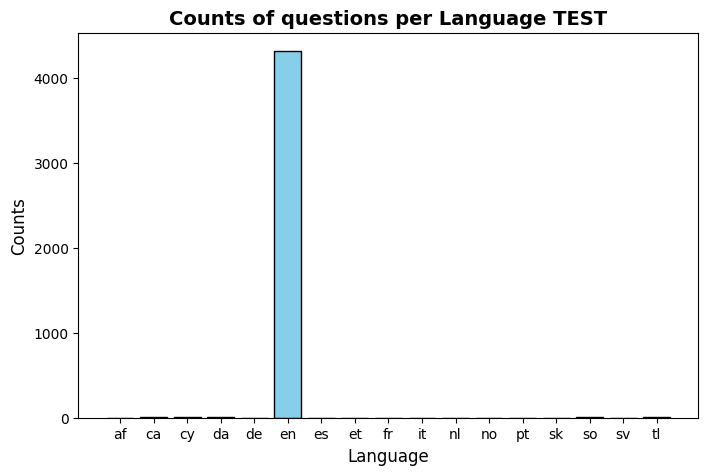

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(res, counts, color="skyblue", edgecolor="black")
plt.title("Counts of questions per Language TEST", fontsize=14, fontweight="bold")
plt.xlabel("Language", fontsize=12)
plt.ylabel("Counts", fontsize=12)

Text(0, 0.5, 'Counts')

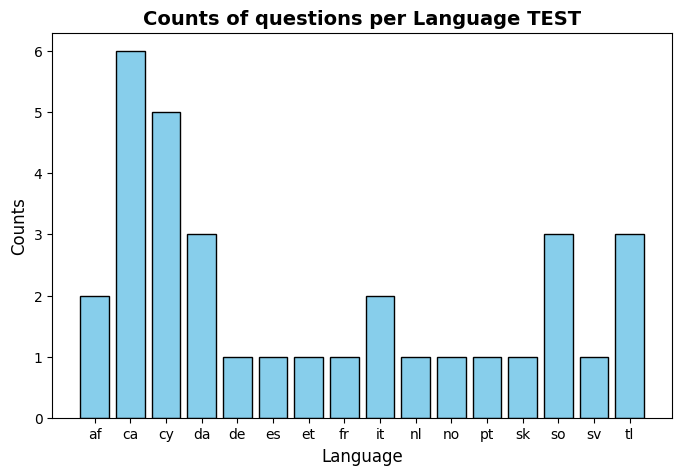

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(np.delete(res,5), np.delete(counts,5), color="skyblue", edgecolor="black")
plt.title("Counts of questions per Language TEST", fontsize=14, fontweight="bold")
plt.xlabel("Language", fontsize=12)
plt.ylabel("Counts", fontsize=12)

In [12]:
test_data["targetCanonType"].unique()

array(['string', 'number', 'date', 'mixed'], dtype=object)

In [13]:
res, counts = np.unique(test_data["targetCanonType"].astype(str), return_counts=True)
print(res, counts)

['date' 'mixed' 'number' 'string'] [  95    4 2200 2045]


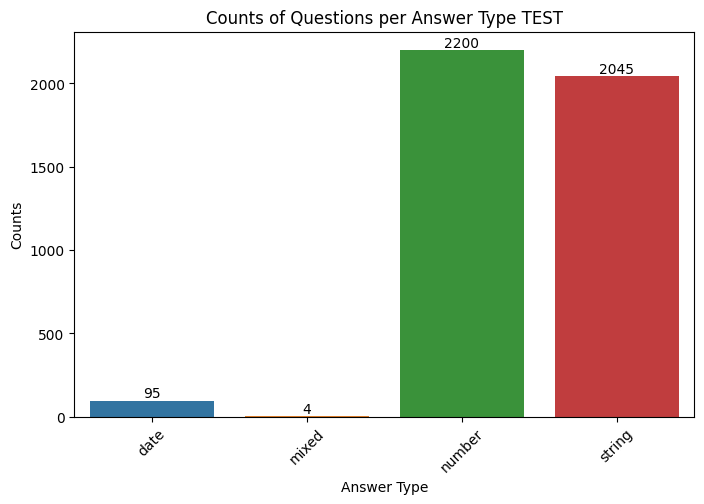

In [14]:
plt.figure(figsize=(8,5))

ax = sns.barplot(x=res, y=counts, palette="tab10", hue=res)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height, str(int(height)),
            ha='center', va='bottom')

plt.title("Counts of Questions per Answer Type TEST")
plt.xlabel("Answer Type")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.show()

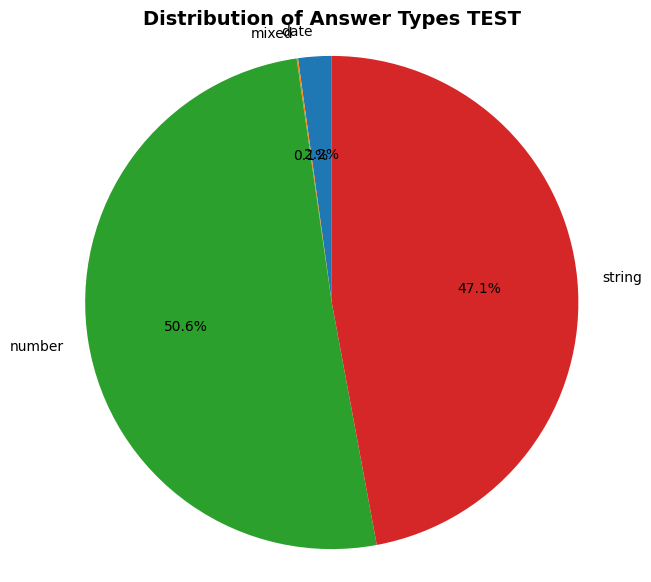

In [15]:
plt.figure(figsize=(7, 7))
plt.pie(
    counts,
    labels=res,
    autopct="%1.1f%%",   
    startangle=90,      
    colors=sns.color_palette("tab10", n_colors=len(res))
)
plt.title("Distribution of Answer Types TEST", fontsize=14, fontweight="bold")
plt.axis("equal") 
plt.show()

## Topic Analysis des questions

In [17]:
# missing_rows = test_data[test_data['lemmaTokens'].isna()]
print(test_data[test_data['lemmaTokens'].isna()].index)


Index([], dtype='int64')


## Extraction de topic 
Il faut reutiliser le count vectorizer entrainer sur les donnees de train, donc la je le fais sur train, et linference sera sur le test

In [19]:
train_data=pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/training_cleaned.tagged")

In [20]:
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
train_data["lemmaTokensJoined"]= train_data["lemmaTokens"].apply(lambda x: ' '.join(x.split('|')) if isinstance(x, str) else '')

dtm = vectorizer.fit_transform(train_data["lemmaTokensJoined"])  


In [21]:
def top_100_words(dict_count):
    most_freq=[]
    i=100
    for w,c in dict_count.items():
        if i>=0: most_freq.append((w,c))
        else:break
        i-=1
    return most_freq

In [22]:

word_counts = np.array(dtm.sum(axis=0)).flatten()
vocab = vectorizer.vocabulary_
freq_dict= {w: word_counts[idx] for w, idx in vocab.items()}
dict_count= dict(sorted(freq_dict.items(), key=lambda item: item[1],reverse=True))

print(top_100_words(dict_count))
# plt.plot(np.sort(word_counts)[::-1])

[('number', 1944), ('total', 1283), ('win', 1218), ('year', 1168), ('list', 967), ('team', 952), ('game', 903), ('time', 762), ('score', 630), ('medal', 557), ('country', 495), ('player', 493), ('play', 486), ('point', 482), ('place', 481), ('season', 408), ('chart', 386), ('finish', 346), ('difference', 337), ('release', 326), ('long', 297), ('title', 272), ('come', 270), ('date', 261), ('race', 249), ('album', 243), ('consecutive', 241), ('song', 240), ('position', 228), ('hold', 228), ('competition', 225), ('film', 221), ('people', 219), ('goal', 219), ('rank', 218), ('gold', 217), ('highest', 217), ('driver', 216), ('award', 211), ('city', 210), ('000', 208), ('population', 203), ('opponent', 202), ('party', 193), ('nation', 193), ('previous', 190), ('10', 181), ('attendance', 175), ('episode', 166), ('largest', 162), ('average', 160), ('championship', 160), ('lrb', 155), ('winner', 154), ('rrb', 154), ('table', 153), ('match', 149), ('record', 148), ('round', 146), ('vote', 142), 

In [23]:
num_topics = 5
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(dtm)

LatentDirichletAllocation(n_components=5, random_state=42)

In [24]:
def print_topics(lda, vectorizer, dict_topics= None, top_n=10): #10 tops words par topic
    words = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(lda.components_):
        
        if dict_topics: print(f"Topic {idx+1}: {dict_topics[idx+1]}") 
        else:  print(f"Topic {idx+1}:")
        print([words[i] for i in topic.argsort()[-top_n:][::-1]])
        print()




In [25]:
dict_topics = {
    1: "Global Sports Tournaments",
    2: "Music Rankings",
    3: "Races and Sporting Events",
    4: "Competitive Events",
    5: "Other"
}

In [26]:
print_topics(lda, vectorizer, dict_topics)

Topic 1: Global Sports Tournaments
['win', 'medal', 'country', 'gold', 'nation', 'number', 'time', 'silver', 'team', 'bronze']

Topic 2: Music Rankings
['year', 'team', 'number', 'title', 'win', 'total', 'play', 'chart', 'album', 'release']

Topic 3: Races and Sporting Events
['game', 'number', 'win', 'time', 'people', 'driver', '000', 'season', 'race', 'attendance']

Topic 4: Competitive Events
['place', 'finish', 'year', 'competition', 'position', 'team', 'release', 'list', 'party', 'come']

Topic 5: Other
['number', 'total', 'list', 'score', 'point', 'player', 'game', 'goal', 'country', 'date']



In [29]:
test_data["lemmaTokensJoined"]= test_data["lemmaTokens"].apply(lambda x: ' '.join(x.split('|')) if isinstance(x, str) else '')
test_dtm = vectorizer.transform(test_data["lemmaTokensJoined"]) 
topic_dist = lda.transform(test_dtm)
topic_dist.shape

(4344, 5)

In [30]:
topic_question= np.argmax(topic_dist, axis=1) #nous donne a quel topic chaque question appartient

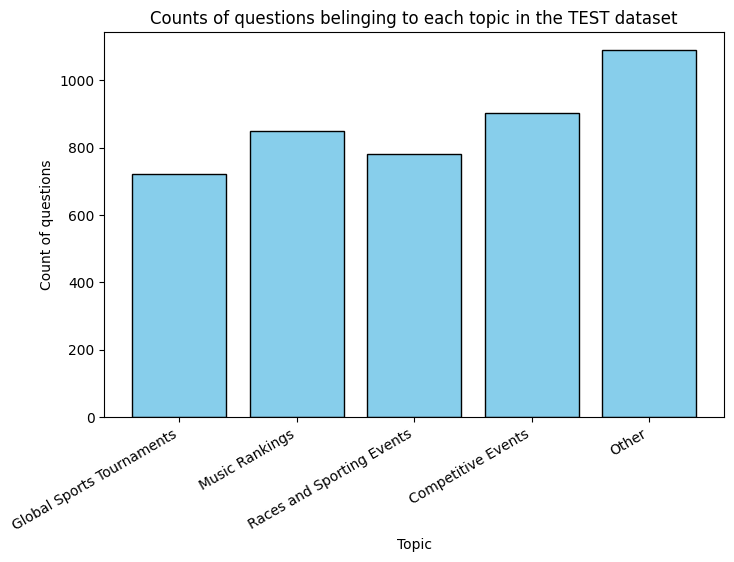

In [31]:
values, counts = np.unique(topic_question, return_counts=True)
labels = [dict_topics[v+1] for v in values]
plt.figure(figsize=(8,5))
plt.bar(labels, counts, color='skyblue', edgecolor='black')
plt.xlabel('Topic')
plt.ylabel('Count of questions')
plt.xticks(rotation=30, ha='right')
plt.title('Counts of questions belinging to each topic in the TEST dataset')
plt.show()

In [32]:
test_data["topic"]=topic_question
test_data.to_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/pristine-unseen-tables_cleaned.tagged", index=False)
test_data=pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/pristine-unseen-tables_cleaned.tagged")
test_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,lemmaTokensJoined,topic
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en,which country have the most cyclist finish wit...,3
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en,how many people be murder in 1940\\/41 ?,3
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en,how long do it take for the new york americans...,1
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en,alfie 's birthday party air on January 19 . wh...,3
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en,what be the number of 1st place finish across ...,3


## Analyse sur les references des colomnes dans la questions.. etc

Do column values appear in the question ? Do questions directly reference values in the table ? Is the answer directly found in the table or does it require some sort of computation ?

In [33]:

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     <local nltk data directory>...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
table_columns=[]
table_values=[]
column_in_question=[]
values_in_question=[]
answer_in_table=[]

for index, row in test_data.iterrows():
    try:
        table= pd.read_csv(f"WikiTableQuestions-1.0.2-compact/WikiTableQuestions/{row['context']}")
        
    except Exception as e:
        try:
            # print("Failed , parser")
            table= pd.read_csv(f"WikiTableQuestions-1.0.2-compact/WikiTableQuestions/{row['context'][:-4]}.table", sep="|", engine="python")
            
            
        except Exception as e2:
            X = []
            print("Failed | parser")
            with open(f"WikiTableQuestions-1.0.2-compact/WikiTableQuestions/{row['context']}", newline='', encoding="utf-8") as f:
                
                reader = csv.reader(f, quotechar='"', escapechar='\\')
                for x in reader:
                    X.append(x)

            table = pd.DataFrame(X[1:], columns=X[0])
    
    table_c=[str(w).strip().lower() for w in table.columns]
    table_v= np.char.strip(np.char.lower(table.values.astype(str)))
    table_columns.append(table_c)
    table_values.append(table_v)
    words= row['tokens'].split('|') if isinstance(row['tokens'], str) else []
    words=[w for w in words if w.lower() not in set(nltk_stopwords.words('english'))]
    isincolumn=any(str(word).lower() in str(cell).lower() for word in words for cell in table_c)
    isinvalue=any(str(word).lower() in str(cell).lower() for word in words for cell in table_v)
    isAnswerinTable = np.any(table_v == str(row['targetValue']).strip().lower())
    column_in_question.append(isincolumn)
    values_in_question.append(isinvalue)
    answer_in_table.append(isAnswerinTable)
    # if isincolumn==False: print('*'*10,table_c,"\n", row['tokens'])


test_data['context_columns']= table_columns    #le nom des colomnes du tableau   
test_data['context_values']= table_values       #valeurs du tableau
test_data['columnInQuestion']= column_in_question   #True si la question contient un mot qu'on retrouve dans les colomnes du tableau  
test_data['valueInQuestion']= values_in_question  #True si la question contient un mot qu'on retrouve dans le tableau
test_data['answerInTable']= answer_in_table

Failed | parser
Failed | parser
Failed | parser
Failed | parser
Failed | parser
Failed | parser
Failed | parser


In [35]:
test_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,lemmaTokensJoined,topic,context_columns,context_values,columnInQuestion,valueInQuestion,answerInTable
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en,which country have the most cyclist finish wit...,3,"[rank, cyclist, team, time, uci protour\npoints]","[[1, alejandro valverde (esp), caisse d'epargn...",False,True,False
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en,how many people be murder in 1940\\/41 ?,3,"[description losses, 1939/40, 1940/41, 1941/42...","[[direct war losses, 360,000, nan, nan, nan, n...",False,True,True
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en,how long do it take for the new york americans...,1,"[year, division, league, reg. season, playoffs...","[[1931, 1.0, asl, 6th (fall), no playoff, nan]...",True,True,False
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en,alfie 's birthday party air on January 19 . wh...,3,"[series #, season #, title, notes, original ai...","[[1, 1, \the charity\"""", alfie, dee dee, and m...",False,True,True
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en,what be the number of 1st place finish across ...,3,"[date, competition, location, country, event, ...","[[31 october 2008, 2008–09 world cup, manchest...",False,False,False


In [36]:
res, counts = np.unique(test_data["columnInQuestion"].astype(str), return_counts=True)
print(res, counts)

['False' 'True'] [1515 2829]


In [37]:
res, counts = np.unique(test_data["answerInTable"].astype(str), return_counts=True)
print(res, counts)

['False' 'True'] [1749 2595]


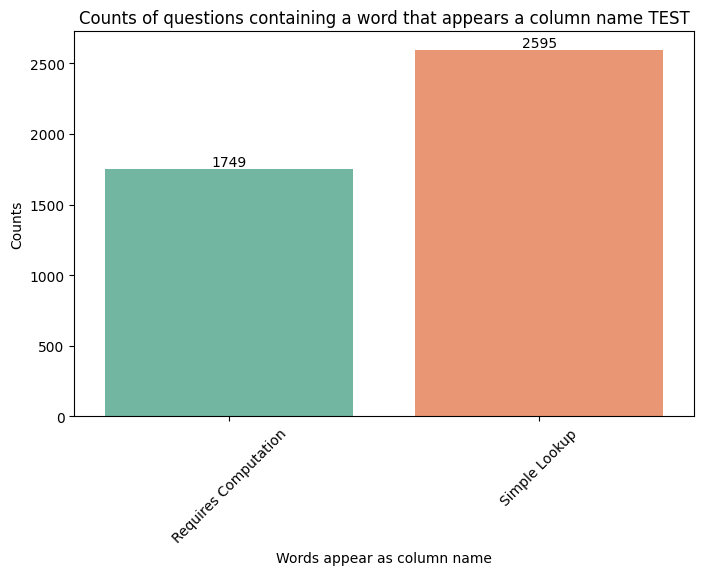

In [42]:
plt.figure(figsize=(8,5))

ax = sns.barplot(x=res, y=counts, palette="Set2", hue=res)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height, str(int(height)),
            ha='center', va='bottom')

plt.title("Counts of questions containing a word that appears a column name TEST")
plt.xlabel("Words appear as column name")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.show()



['Requires Computation', 'Simple Lookup'] [1749 2595]


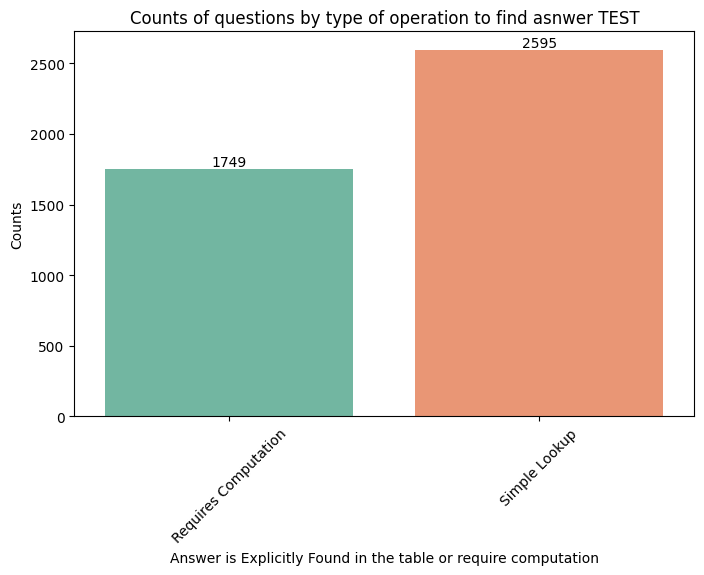

In [41]:
res, counts = np.unique(test_data["answerInTable"].astype(str), return_counts=True)
res=["Requires Computation", "Simple Lookup"]
print(res, counts)

plt.figure(figsize=(8,5))

ax = sns.barplot(x=res, y=counts, palette="Set2", hue=res)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height, str(int(height)),
            ha='center', va='bottom')

plt.title("Counts of questions by type of operation to find asnwer TEST")
plt.xlabel("Answer is Explicitly Found in the table or require computation")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.show()


In [43]:
res, counts = np.unique(test_data["valueInQuestion"].astype(str), return_counts=True)
print(res, counts)

['False' 'True'] [1199 3145]


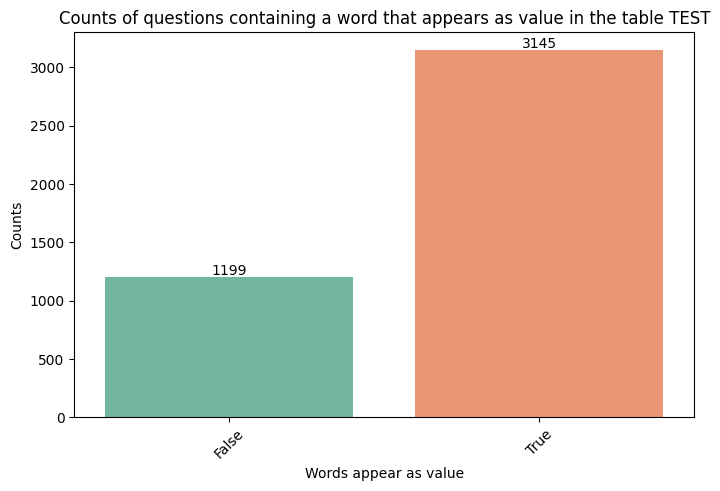

In [44]:
plt.figure(figsize=(8,5))

ax = sns.barplot(x=res, y=counts, palette="Set2", hue=res)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height, str(int(height)),
            ha='center', va='bottom')

plt.title("Counts of questions containing a word that appears as value in the table TEST")
plt.xlabel("Words appear as value")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.show()

In [45]:
test_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,lemmaTokensJoined,topic,context_columns,context_values,columnInQuestion,valueInQuestion,answerInTable
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en,which country have the most cyclist finish wit...,3,"[rank, cyclist, team, time, uci protour\npoints]","[[1, alejandro valverde (esp), caisse d'epargn...",False,True,False
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en,how many people be murder in 1940\\/41 ?,3,"[description losses, 1939/40, 1940/41, 1941/42...","[[direct war losses, 360,000, nan, nan, nan, n...",False,True,True
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en,how long do it take for the new york americans...,1,"[year, division, league, reg. season, playoffs...","[[1931, 1.0, asl, 6th (fall), no playoff, nan]...",True,True,False
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en,alfie 's birthday party air on January 19 . wh...,3,"[series #, season #, title, notes, original ai...","[[1, 1, \the charity\"""", alfie, dee dee, and m...",False,True,True
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en,what be the number of 1st place finish across ...,3,"[date, competition, location, country, event, ...","[[31 october 2008, 2008–09 world cup, manchest...",False,False,False


In [47]:
test_data.drop(columns=["context_columns","context_values","lemmaTokensJoined"], inplace=True)
test_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,answerInTable
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en,3,False,True,False
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en,3,False,True,True
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en,1,True,True,False
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en,3,False,True,True
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en,3,False,False,False


In [48]:
test_data.to_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/pristine-unseen-tables_cleaned.tagged", index=False)
test_data=pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/pristine-unseen-tables_cleaned.tagged")
test_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,answerInTable
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en,3,False,True,False
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en,3,False,True,True
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en,1,True,True,False
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en,3,False,True,True
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en,3,False,False,False


In [49]:
len(test_data)

4344

## Anlaysis of different question types

In [50]:
def question_type(row):
    question = str(row['utterance']).lower()
    answer = str(row['targetValue']).lower()

    if 'yes' in answer or 'no' in answer:
        return "Yes/No question"

    if any(word in question for word in ["how many","how long", "how much", "count", "number of"]):
        return "Numerical question"

    if any(word in question for word in ["when", "what year", "date", "month", "day"]):
        return "Temporal question"

    if any(word in question for word in ["more than", "less than", "better"]):
        return "Comparative question"

    if any(word in question for word in ["most", "least", "best", "worst", "highest", "lowest"]):
        return "Superlative question"

    if any(word in question for word in ["what is", "who is", "where is"]):
        return "Fact question"

    if any(word in question for word in ["list", "name", "show all"]):
        return "List question"

    return "Other question"



In [51]:

test_data['question_type'] = test_data.apply(question_type, axis=1)
test_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,answerInTable,question_type
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en,3,False,True,False,Numerical question
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en,3,False,True,True,Numerical question
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en,1,True,True,False,Numerical question
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en,3,False,True,True,Temporal question
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en,3,False,False,False,Numerical question


In [52]:
test_data.to_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/pristine-unseen-tables_cleaned.tagged", index=False)
test_data=pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/pristine-unseen-tables_cleaned.tagged")
test_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,answerInTable,question_type
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en,3,False,True,False,Numerical question
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en,3,False,True,True,Numerical question
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en,1,True,True,False,Numerical question
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en,3,False,True,True,Temporal question
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en,3,False,False,False,Numerical question


## updated full testing dataset


In [53]:
test_data=pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/pristine-unseen-tables_cleaned.tagged")
test_data.head()
#Nouvelle colomnes: utterance_lng	topic	columnInQuestion	valueInQuestion	answerInTable	question_type

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,answerInTable,question_type
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en,3,False,True,False,Numerical question
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en,3,False,True,True,Numerical question
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en,1,True,True,False,Numerical question
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en,3,False,True,True,Temporal question
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en,3,False,False,False,Numerical question


# ENGLISH DATASET

In [54]:
test_data_en= test_data[test_data["utterance_lng"]=='en']
print("Nb of questions is english dataset:", len(test_data_en))

print("Nb of table in english dataset:", len(test_data_en["context"].unique()))

Nb of questions is english dataset: 4311
Nb of table in english dataset: 421


In [55]:
print("Nb of questions is full dataset:", len(test_data))

print("Nb of table in full dataset:", len(test_data["context"].unique()))
test_data_en.to_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_pristine-unseen-tables_cleaned.tagged", index=False)

Nb of questions is full dataset: 4344
Nb of table in full dataset: 421


In [56]:

test_data_en=pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_pristine-unseen-tables_cleaned.tagged")
test_data_en.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,answerInTable,question_type
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en,3,False,True,False,Numerical question
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en,3,False,True,True,Numerical question
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en,1,True,True,False,Numerical question
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en,3,False,True,True,Temporal question
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en,3,False,False,False,Numerical question


## Analysis of english test dataset

In [57]:
import pandas as pd
import csv
test_data_en=pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_pristine-unseen-tables_cleaned.tagged")

In [58]:
test_data_en.shape

(4311, 17)

In [59]:
len(test_data_en["context"].unique()) #nb of tables

421

In [60]:
test_data_en.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,answerInTable,question_type
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en,3,False,True,False,Numerical question
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en,3,False,True,True,Numerical question
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en,1,True,True,False,Numerical question
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en,3,False,True,True,Temporal question
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en,3,False,False,False,Numerical question


In [61]:
#count of nan values per column
test_data_en.isna().sum()


id                  0
utterance           0
context             0
targetValue         0
tokens              0
lemmaTokens         0
posTags             0
nerTags             0
nerValues           0
targetCanon         0
targetCanonType     0
utterance_lng       0
topic               0
columnInQuestion    0
valueInQuestion     0
answerInTable       0
question_type       0
dtype: int64

In [62]:
len(test_data_en["context"].unique()) #nb of tables

421

In [63]:
res, counts = np.unique(test_data_en["targetCanonType"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)

['date' 'mixed' 'number' 'string'] [  94    4 2183 2030] [ 2.18046857  0.0927859  50.63790304 47.0888425 ]


In [64]:
res, counts = np.unique(test_data_en["topic"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)

['0' '1' '2' '3' '4'] [ 717  842  773  900 1079] [16.63187196 19.53143122 17.93087451 20.87682672 25.02899559]


In [65]:
res, counts = np.unique(test_data_en["columnInQuestion"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)


['False' 'True'] [1500 2811] [34.7947112 65.2052888]


In [66]:
res, counts = np.unique(test_data_en["valueInQuestion"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)

['False' 'True'] [1196 3115] [27.74298307 72.25701693]


In [67]:
res, counts = np.unique(test_data_en["question_type"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)

['Comparative question' 'Fact question' 'List question'
 'Numerical question' 'Other question' 'Superlative question'
 'Temporal question' 'Yes/No question'] [  60  329  151 1915 1125  352  217  162] [ 1.39178845  7.63163999  3.50266759 44.42124797 26.0960334   8.1651589
  5.03363489  3.75782881]


In [68]:
res, counts = np.unique(test_data_en["answerInTable"].astype(str), return_counts=True)
percentages= counts*100/counts.sum()
print(res, counts, percentages)

['False' 'True'] [1735 2576] [40.24588263 59.75411737]
